# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## Setup

Import packages required for the analysis

In [1]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [3]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph
from scipy.signal import convolve2d

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
from pyquadkey2 import quadkey

In [4]:
# Climate/Flood
# import xarray as xr

In [5]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [6]:
# auto reload
%load_ext autoreload
%autoreload 2

Define below the local folder where you are located

In [7]:
data_dir = join(expanduser("/home/jupyter-wb618081"), 'data')
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics')
out_path = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Output')

## Data Preparation

### Administrative boundaries

In [8]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:32736"

In [9]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)
adm2 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=2)

In [10]:
# iso = 'MWI'
# adm0_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin0_Polys.shp')
# adm0 = gpd.read_file(adm0_path)
# adm0 = adm0[adm0["ISO3"] == "MWI"].to_crs(4326)

# iso = 'MWI'
# adm2_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin2_Polys.shp')
# adm2 = gpd.read_file(adm2_path)
# adm2 = adm2[adm2["ISO3"] == "MWI"].to_crs(4326)

### Population (origin)

In [11]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'ppp_2020_1km_Aggregated.tif') # Download from link above

pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [12]:
hf_path = join(data_dir,'MWI','HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)

display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(df_hf["Facility Type"].value_counts())

# Consider all health facilities and hospitals

df_hf_hosp = df_hf.loc[df_hf['Facility Type'] == "Hospital"]

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

Facility Type
Outreach          5090
Village Clinic    3542
Health Centre      542
Health Post        152
Dispensary          87
Hospital            85
Name: count, dtype: int64

In [13]:
# Convert from pandas.Dataframe to Geopandas.dataframe

geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs=epsg
)

geodf_hf_hosp = gpd.GeoDataFrame(
    df_hf_hosp, geometry=gpd.points_from_xy(df_hf_hosp.Eastings, df_hf_hosp.Northings), crs=epsg
)

# Clean the geodf
geodf_hf = geodf_hf[['Facility Name', 'Facility Type','District', 'TA', 'geometry']]; geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf_hosp = geodf_hf_hosp[['Facility Name', 'Facility Type', 'District', 'TA', 'geometry']]; geodf_hf_hosp.loc[:, 'ID'] = df_hf_hosp.index


Assure correspondence of ADM1 names in Health facilities and official Administrative Units

In [14]:
geodf_hf.rename(columns={'District': 'ADM1', 'TA': 'ADM2'}, inplace=True)
geodf_hf_hosp.rename(columns={'District': 'ADM1', 'TA': 'ADM2'}, inplace=True)
adm1.rename(columns={"NAME_1":"ADM1"}, inplace=True) 

# The following ADM1 are not corresponding
miss_adm1 = np.setdiff1d(np.sort(geodf_hf.ADM1.unique()), np.sort(adm1.ADM1.unique()))
display(miss_adm1)
display(np.setdiff1d(np.sort(adm1.ADM1.unique()), np.sort(geodf_hf.ADM1.unique())))

array(['Mzimba North', 'Mzimba South'], dtype=object)

array(['Mzimba'], dtype=object)

In [15]:
for adm in miss_adm1:
    for idx in (geodf_hf[geodf_hf.ADM1 == adm].index):
            geodf_hf.loc[idx, 'ADM1'] = 'Mzimba'

    for idx_hosp in (geodf_hf_hosp[geodf_hf_hosp.ADM1 == adm].index):
            geodf_hf_hosp.loc[idx_hosp, 'ADM1'] = 'Mzimba'

### Flood

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [16]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

# inland waters and oceans: 999
# not-flooded areas: -999 (Fluvial)
# not-flooded areas: 0 (Pluvial)
# Other values represent the flood depth (in m)

flood_fluvial_path = join(data_dir, iso,'FLOOD_SSBN','fluvial_undefended')
flood_pluvial_path = join(data_dir, iso,'FLOOD_SSBN','pluvial')

files=os.listdir(flood_fluvial_path)
flood_dict_fluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_fluvial_path,file)) #.read(1)
    flood_dict_fluvial[key] = value

files=os.listdir(flood_pluvial_path)
flood_dict_pluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_pluvial_path,file)) #.read(1)
    flood_dict_pluvial[key] = value

# Preserve the maximum flood depth
flood_dict = {}
for f,key in enumerate(flood_dict_pluvial.keys()):
    out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key +'.tif')
    if os.path.isfile(out_flood_path):
        value = rio.open(out_flood_path) 
        flood_dict[key] = value
    else:
        out_meta = flood_dict_pluvial[key].meta
        flood_max = np.fmax(flood_dict_fluvial[key].read(1),flood_dict_pluvial[key].read(1))
        flood_dict[key] = flood_max
        # flood_dict[key][flood_dict[key] == 0] = -999
        # Write the output raster
        out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key +'.tif')
        with rio.open(out_flood_path, 'w', **out_meta) as dst:
            dst.write(flood_max, 1)
        # Read the output raster
        value = rio.open(out_flood_path) 
        flood_dict[key] = value

### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [17]:
# Only the first time, clip the travel friction surface to the country of interest
out_travel_surface = join(data_dir, iso, f"travel_surface_motorized_{iso}.tif")

if not os.path.isfile(out_travel_surface):
    gfs_path = join(data_dir, '2020_motorized_friction_surface.geotiff')
    gfs_rio = rio.open(gfs_path)
    rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

# Import the clipped friction surface
travel_surf = rio.open(out_travel_surface) #.read(1)

In [18]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


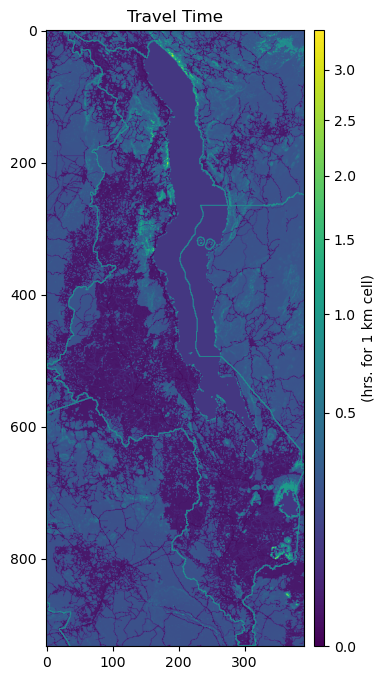

In [19]:
fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Travel Time", fontsize=12, horizontalalignment='center')
im = ax.imshow(travel_surf.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("(hrs. for 1 km cell)")

### Preprocessing



Align the POPULATION & FLOOD raster to the friction surface, ensuring that they have the same extent and resolution.

In [20]:
# If the Standardized data are already present, skip, else generate them

def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

out_pop_surface_std = join(out_path, iso, "WP_2020_1km_STD.tif")
if not os.path.isfile(out_pop_surface_std):
    rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

checkDir(join(scratch_dir, 'data', iso, 'flood'))

for f,key in enumerate(flood_dict.keys()):
    # out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key)
    out_flood_std = join(out_path, iso, 'flood', "STD_" + 'Fmax_'+ key +'.tif')
    if os.path.isfile(out_flood_std):
        None
    else:
        rMisc.standardizeInputRasters(flood_dict[key], travel_surf, out_flood_std, resampling_type="nearest")

Correct the reprojected FLOOD raster extension, ensuring that lands are not covered by inland and open waters

In [21]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

flood_path = join(out_path, iso, 'flood')
files=os.listdir(flood_path)

flood_dict_std = {}
for file in files:
    if file.startswith('STD') == True:
        key = file.split('_')[2].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        flood_dict_std[key] = value

display(flood_dict_std["1in10"].read_crs())

CRS.from_epsg(4326)

In [22]:
# # Correct Flood Raster extension, by replacing pixels with value == 999 (inland/open waters) is they overlap a land geometry

# def flood_correction(arr, land_shp, out_path_flood, exclude_value):
#     # arr: rasterio dataset (not readed yet)
    
#     flood_data = arr.read(1).copy()
    
#     # Mask land geometries (True inside)
#     geom_mask = geometry_mask([mapping(geometry) for geometry in land.geometry], 
#                               invert=True, transform=arr.transform, 
#                               all_touched=True, out_shape=(arr.height, arr.width))
    
#     flood_data[geom_mask] = -999
#     correct_mask = np.logical_and(flood_data == -999, arr.read(1) == exclude_value)
    
#     # Create a kernel to look at all neighboring cells
#     kernel = np.ones((3, 3))
#     kernel[1, 1] = 0  # Do not include the cell itself
    
#     # Temporarily replace 999 with np.nan for mean calculation
#     flood_data_with_nan = arr.read(1).copy()
#     flood_data_with_nan[flood_data_with_nan == exclude_value] = np.nan

#     # Temporarily replace np.nan with 0 for convolution and count valid (non-np.nan) neighbors
#     temp_data = np.nan_to_num(flood_data_with_nan, nan=0)
#     valid_neighbors = np.where(flood_data_with_nan != np.nan, 1, 0)

    
#     # Calculate sum and count of neighbors excluding np.nan (previously 999)
#     neighbor_sum = convolve2d(temp_data, kernel, mode='same', boundary='fill', fillvalue=0)
#     neighbor_count = convolve2d(valid_neighbors, kernel, mode='same', boundary='fill', fillvalue=0)
    
#     # Avoid division by zero for locations with all neighbors as np.nan (or originally 999)
#     with np.errstate(divide='ignore', invalid='ignore'):
#         neighbor_mean = neighbor_sum / neighbor_count
#         neighbor_mean[neighbor_count == 0] = np.nan  # Re-assign NaN to locations with no valid neighbors
    
#     # Replace the original values with the computed means where correct_mask is True
#     arr_corrected = arr.read(1).copy()
#     arr_corrected[correct_mask] = neighbor_mean[correct_mask]
    
#     # If necessary, revert np.nan back to 999 in flood_data
#     # flood_data[np.isnan(flood_data)] = exclude_value
    
#     # Save the corrected flood raster
#     out_meta = arr.meta
#     with rio.open(out_path_flood, 'w', **out_meta) as dst:
#             dst.write(flood_data, 1)

#     # Open the corrected flood raster
#     # value = rio.open(out_path_flood) 
#     # flood_data = value
#     return arr_corrected

# land = gpd.read_file(join(data_dir, iso, "geoBoundaries", "geoBoundaries-"+iso+"-ADM1_simplified.shp"))

# flood_dict_correct = {}
# for f,key in enumerate(flood_dict.keys()):
#     out_flood_std = join(out_path, iso, 'flood', "STD_" + 'Fmax_'+ key +'_correct1.tif')
    
#     flood_dict_correct[key] = flood_correction(flood_dict_std[key], land, out_flood_path, 999)

# flood_dict_correct["1in100"] = flood_correction(flood_dict_std["1in100"], land, join(out_path, iso, 'flood', "STD_" + 'Fmax_'+ "1in100" +'_codio.tif'), 999)

### Origins

Prepare a standard grid (pandas.Dataframe) using each cell from the 1km World Pop raster.

In [23]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)

(32.67083333333333, -9.3625)

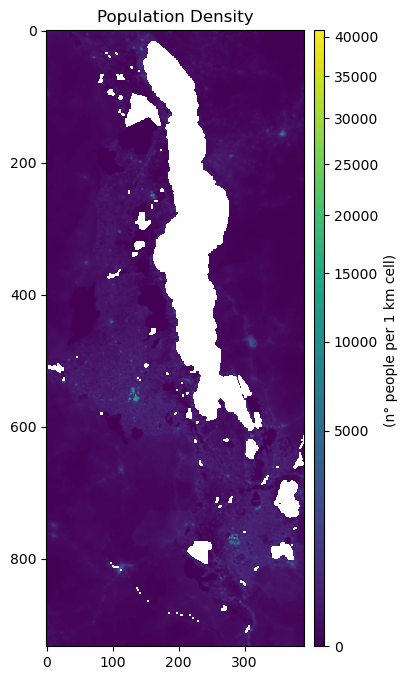

In [24]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Population Density", fontsize=12, horizontalalignment='center')
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("(n° people per 1 km cell) ")

pop_surf.xy(0,0)

In [25]:
# Create a population df from population surface 
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4
...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868


## Flood impact on Health facilities

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution\
For every Standardized Flood layer (Return Period), extract Flood Depth on Health Facilities location

In [208]:
# Extract flood depth at every facility location

for key in flood_dict.keys():
    coords = [(x,y) for x, y in zip(geodf_hf_hosp.geometry.x, geodf_hf_hosp.geometry.y)]
    geodf_hf_hosp[key] = [x[0] for x in flood_dict[key].sample(coords)]

    coords = [(x,y) for x, y in zip(geodf_hf.geometry.x, geodf_hf.geometry.y)]
    geodf_hf[key] = [x[0] for x in flood_dict[key].sample(coords)]


In [209]:
# Identify Flooded and not Flooded Facilities 

flood_geodf_hf_hosp = {}
dry_geodf_hf_hosp = {}
flood_geodf_hf = {}
dry_geodf_hf = {}
for key in flood_dict.keys():
    flood_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] > 0.2]
    dry_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] == 0]
    
    flood_geodf_hf[key] = geodf_hf[geodf_hf[key] > 0.2]
    dry_geodf_hf[key] = geodf_hf[geodf_hf[key] == 0]


### Summary statistics

For every Flood Scenario (RP):
- Number and % of Health facilities disrupted by Facility Type
- Number and % of Health facilities disrupted by ADM1 Districts

In [91]:
# Reorder Flood Return Periods in geodf columns

def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if col.startswith(str_start)]
    non_fd_columns = [col for col in gdf.columns if not col.startswith(str_start)]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

geodf_hf = sort_flood_col(geodf_hf, "1in", "in")
geodf_hf_hosp = sort_flood_col(geodf_hf_hosp, "1in", "in")

In [92]:
# % of Facilities disrupted, by Facility Type

stats1 = geodf_hf[geodf_hf != 0].groupby("Facility Type").count().drop(columns = ["Facility Name", "ADM1", "ADM2", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats1.columns if col.startswith("1in")]
for col in fd_columns:
    stats1[col] = (stats1[col]/stats1["Total n°"])*100

stats1[fd_columns] = stats1[fd_columns].round(2)
display(stats1)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000
Facility Type,,,,,,,,,,,
Dispensary,87,6.90,10.34,13.79,16.09,16.09,17.24,20.69,21.84,24.14,25.29
Health Centre,542,6.27,8.49,9.59,12.73,13.65,14.58,16.42,16.61,18.63,19.56
Health Post,152,14.47,18.42,21.71,22.37,23.68,23.68,25.66,26.32,26.97,29.61
Hospital,84,3.57,3.57,3.57,3.57,3.57,3.57,4.76,4.76,7.14,9.52
Outreach,5090,7.70,10.53,12.73,15.30,16.44,17.43,19.17,19.57,21.96,23.63
Village Clinic,3542,7.40,10.19,12.54,15.19,16.29,17.11,19.11,19.34,21.46,23.57


In [93]:
stats1_long = pd.melt(stats1.reset_index().drop(columns = "Total n°"), id_vars="Facility Type", var_name="scen")
scen = stats1_long.scen.unique()

In [94]:
# % of Facilities disrupted, by ADM1 (Districts)

stats2 = geodf_hf[geodf_hf != 0].groupby("ADM1").count().drop(columns = ["Facility Name", "Facility Type", "ADM2", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats2.columns if col.startswith("1in")]
for col in fd_columns:
    stats2[col] = (stats2[col]/stats2["Total n°"])*100

stats2[fd_columns] = stats2[fd_columns].round(2)

# Merge with ADM1 geometries
stats2 = stats2.merge(adm1[["ADM1", "geometry"]], on='ADM1', how='left').set_index("ADM1")
stats2 =gpd.GeoDataFrame(stats2, geometry=stats2["geometry"], crs="EPSG:4326")
display(stats2)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000,geometry
ADM1,,,,,,,,,,,,
Balaka,320,15.31,20.31,23.75,29.69,30.00,30.31,33.12,33.12,34.06,35.94,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
Blantyre,276,7.61,10.51,11.59,13.04,14.49,15.22,15.94,15.94,17.75,17.75,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."
Chikwawa,290,12.41,19.31,23.79,26.90,29.66,34.48,37.24,37.59,43.45,45.86,"MULTIPOLYGON (((34.92864 -16.64210, 34.92845 -..."
Chiradzulu,156,1.92,7.05,9.62,12.18,12.18,12.18,12.18,12.18,12.18,12.82,"MULTIPOLYGON (((35.32407 -15.91358, 35.32412 -..."
Chitipa,213,3.76,3.76,4.23,5.63,5.63,6.57,8.92,8.92,8.92,10.80,"MULTIPOLYGON (((33.75890 -10.23768, 33.79720 -..."
Dedza,389,5.66,7.20,8.23,10.03,10.54,10.80,13.11,13.11,15.68,17.48,"MULTIPOLYGON (((34.03575 -14.48153, 34.03575 -..."
Dowa,559,2.50,3.04,5.01,7.16,8.23,9.30,9.84,10.38,12.16,13.77,"MULTIPOLYGON (((34.18658 -13.69968, 34.18738 -..."
Karonga,281,27.76,33.10,38.79,44.48,46.62,48.40,50.89,51.60,53.74,55.87,"MULTIPOLYGON (((34.17258 -10.58059, 34.17202 -..."
Kasungu,660,0.61,0.91,1.36,2.42,3.64,4.09,4.85,5.00,6.21,6.52,"MULTIPOLYGON (((33.36169 -13.58856, 33.36145 -..."


### Map HF Impact Results

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


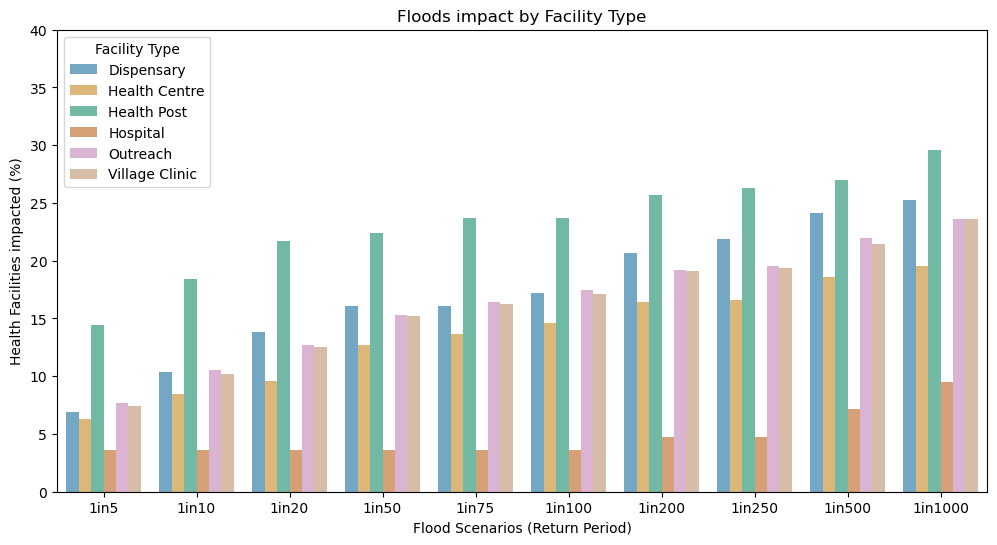

In [95]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Floods impact by Facility Type")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios (Return Period)")
ax0.set_ylabel("Health Facilities impacted (%)")
ax0.set_ylim(0,40)
ax0.legend(loc='upper left', fontsize = 10, title = "Facility type")
ax0 = sns.barplot(
    data=stats1_long, hue="Facility Type",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

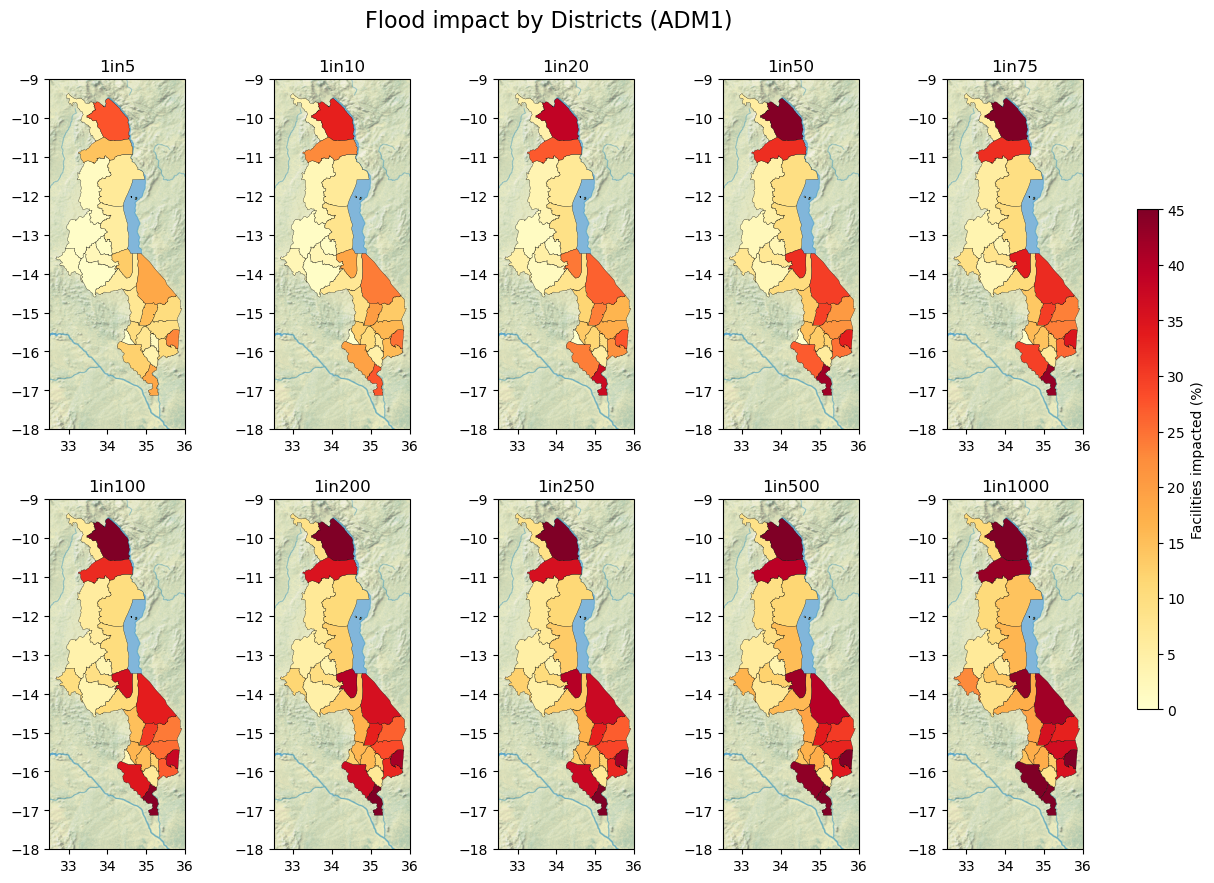

<Figure size 640x480 with 0 Axes>

In [97]:
figsize = (14, 10)
fig = plt.figure(figsize=figsize)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 5)

title = "Flood impact by Districts (ADM1)"
fig.suptitle(title, size=16, y=0.95)

# Define the colormap
cmap = plt.get_cmap('YlOrRd')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=45)

for i, flood in enumerate(scen):
    if i < 5:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, i-5], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    # Plot the data
    stats2.plot(
        ax=ax, column=flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )

    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])
    
# Add a colorbar to the figure, adjusting its position via `fig.add_axes`
cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Facilities impacted (%)")

plt.show()
plt.savefig(join(out_path, iso, title + ".png"), dpi=300, bbox_inches='tight', facecolor='white')

## Flood impact on Friction Surface

Consider the Standardized Fmax flood rasters, thus exploiting the original FATHOM dataset resolution\
We consider different degrees of accessibility/mobility disruption according to different flood depth (FD) levels

- If the FD is less than 0.3 meters, than accessibility is preserved but signifcantly impacted (slowered)
- If the FD is higher than 0.3 meters, than mobility is interrupted on that specific pathway

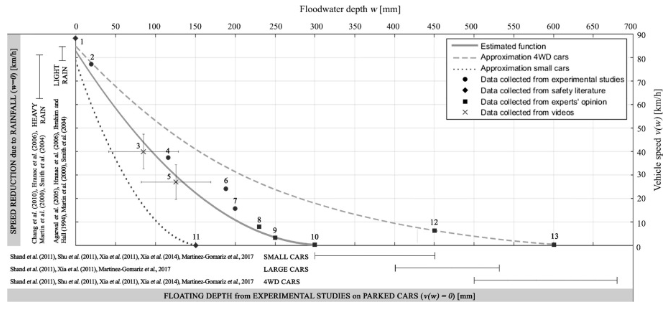

In [26]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

flood_path = join(out_path, iso, 'flood')
files=os.listdir(flood_path)

flood_dict_std = {}
for file in files:
    if file.startswith('STD') == True:
        key = file.split('_')[2].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        flood_dict_std[key] = value

display(flood_dict_std["1in10"].read_crs())

CRS.from_epsg(4326)

In [202]:
# Create weights for the Friction Surface
# If water level is less than 30 cm, accessibility is affected (from pregnolato et al., (2017))
# If water level is more than 30 cm, accessibility is disrupted (travel time *50)

def friction_flood_weight(flood_rio):
    ''' Generate flood derived weights for the friction surface 
    
    INPUTS
        flood_rio [rasterio] - raster with flood depths from which to generate weights
  
    RETURNS
        flood_rio [rasterio] - raster with weights 
    ''' 
    
    from scipy.interpolate import interp1d

    # Function for scale Flood Depth array between 1 (min) and 0 (max)
    def scale_array(arr):
        min_val = np.min(arr)
        max_val = np.max(arr)
        scaled_arr = (arr - min_val) / (max_val - min_val)
        scaled_arr = 1 - scaled_arr  # Invert the scaled values
        return scaled_arr
    
    flood_rio = flood_rio.read(1)
    flood_rio_orig = flood_rio.copy()

    # Apply the quadratic (parabolic) relationship from Pregnolato et al., (2017)
    # Describes the vehicles max speed according to Flood Depth values (in mm) 
    flood_arr = flood_rio[(flood_rio_orig > 0) & (flood_rio_orig < 0.3)]*1000   # flood depth from m to mm
    depth_val = np.arange(1,300,0.1)     # Define discrete Flood Depth values between 1 mm and 300 mm
    func = scale_array(9*10**(-4)*(depth_val**2) - 0.5529*depth_val + 86.9448)   # eq.4 from Pregnolato et al., (2017)
    # Scale the function with the maximum vehicles speed
    func = func*func.max()**-1
    interp_func = interp1d(depth_val, func, kind='linear', fill_value='extrapolate')
    flood_arr_weight = interp_func(flood_arr)

    # Flood Depth < 0 or 999 (open waters) -> 0
    # Flood Depth > 30 cm                  -> 50
    # Flood Depth > 0 & < 30 cm            -> inverse of quadratic function (between 1 and 20 circa)
    flood_rio[(flood_rio_orig > 0) & (flood_rio_orig < 0.3)] = 1/flood_arr_weight
    flood_rio[(flood_rio_orig <= 0) | (flood_rio_orig == 999)] = 1
    flood_rio[(flood_rio_orig >= 0.3) & (flood_rio_orig < 999)] = 50

    # To ensure that weights are always >1 (avoid decresing travel time)
    flood_rio[(flood_rio <1)] = 1
    
    del flood_rio_orig
    return flood_rio


In [204]:
flood_dict_fd = flood_dict_std.copy()

for key in flood_dict_fd.keys():

    flood_dict_fd[key] = friction_flood_weight(flood_dict_fd[key])

Create new Friction Surface that accounts for Floods disruption 

In [205]:
# Weight the Friction Surface with the discrete flood depth array

travel_surf_flood = dict()
for key in flood_dict_fd.keys():
    travel_surf_flood[key] = travel_surf.read(1) * flood_dict_fd[key]


Create an MCP graph object from the flooded friction surfaces.

In [206]:
# convert friction surface to traversal time (lazily). Original data are minutes to travel 1 m:
# We convert it to minutes to cross the cell (1000m). This could be revised

inG_data = dict()
inG_data["baseline"] = travel_surf.read(1) * 1000
for key in travel_surf_flood.keys():
    inG_data[key] = travel_surf_flood[key] * 1000

# Correct no data values. Not needed but good to check
# inG_data[inG_data < 0] = 99999999
# inG_data[inG_data < 0] = np.nan

mcp = dict()
mcp["baseline"] = graph.MCP_Geometric(inG_data["baseline"])
for key in inG_data.keys():
    mcp[key] = graph.MCP_Geometric(inG_data[key])

# Check descriptive statistics
print(f"Mean: {np.mean(inG_data['1in5'])}")
print(f"Max: {np.max(inG_data['1in5'])}")
print(f"Min: {np.min(inG_data['1in5'])}")
print(f"Std: {np.std(inG_data['1in5'])}")

Mean: 16.180652618408203
Max: 8287.5048828125
Min: 0.5
Std: 91.2672348022461


## Data analysis

**Indicators of interest**

Percentage of population within 2h of driving to the nearest primary care facility (population level, and by SES quintile). \
Percentage of population within 2h of driving to the nearest district hospital (population, and by SES quintile). \
Percentage of health facilities with direct access to an all season road. \
Percentage of health facilities within 2km of an all season road.


In [210]:
# Calculate the travel time from each grid-cell to the nearest not-flooded destination
# According to the Flood scenario, we'll a different number of flooded facilities  

res_hf = dict()
res_hf_hosp = dict()
res_hf["baseline"] = ma.calculate_travel_time(travel_surf, mcp["baseline"], geodf_hf)[0]
res_hf_hosp["baseline"] = ma.calculate_travel_time(travel_surf, mcp["baseline"], geodf_hf_hosp)[0]
for key in travel_surf_flood.keys():
    res_hf[key] = ma.calculate_travel_time(travel_surf, mcp[key], dry_geodf_hf[key])[0]
    res_hf_hosp[key] = ma.calculate_travel_time(travel_surf, mcp[key], dry_geodf_hf_hosp[key])[0]

# Check dimension
display(len(res_hf[key].flatten()), len(dry_geodf_hf_hosp[key]))

# Decide to consider all facilities or Hospitals
res_df.loc[:, 'tt_hf_' + "baseline"] = res_hf["baseline"].flatten()
res_df.loc[:, 'tt_hosp_' + "baseline"] = res_hf_hosp["baseline"].flatten()
for key in travel_surf_flood.keys():
    res_df.loc[:, 'tt_hf_' + key] = res_hf[key].flatten()
    res_df.loc[:, 'tt_hosp_' + key] = res_hf_hosp[key].flatten()

# remove values where pop is 0 or nan
res_df = res_df.loc[res_df['pop']!=0].copy()
res_df = res_df.loc[~(res_df['pop'].isna())].copy()

res_df.loc[:,'xy'] = res_df.loc[:,'xy'].apply(lambda x: Point(x))

res_df.head(2)

363870

81

,spatial_index,xy,pop,pointid,tt_hf_baseline,tt_hosp_baseline,tt_hf_1in100,tt_hosp_1in100,tt_hf_1in1000,tt_hosp_1in1000,...,tt_hf_1in250,tt_hosp_1in250,tt_hf_1in20,tt_hosp_1in20,tt_hf_1in5,tt_hosp_1in5,tt_hf_1in50,tt_hosp_1in50,tt_hf_1in200,tt_hosp_1in200
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0,205.364383,205.364383,212.504426,212.504426,217.231925,217.231925,...,211.680068,211.680068,209.776903,209.776903,209.552599,209.552599,213.104327,213.104327,211.806125,211.806125
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1,203.864383,203.864383,211.004426,211.004426,215.731925,215.731925,...,210.180068,210.180068,208.276903,208.276903,208.052599,208.052599,211.604327,211.604327,210.306125,210.306125


Create Geodataframe for the population grid

In [211]:
res_gdf = gpd.GeoDataFrame(res_df, geometry='xy', crs=epsg)
res_gdf.rename(columns={'xy':'geometry'}, inplace=True)
res_gdf.set_geometry('geometry', inplace=True)

# convert travel time from minutes to hours
for col in res_gdf.columns:
    if 'tt_' in col:
        res_gdf.loc[:, col] = res_gdf.loc[:, col] / 60
        
res_gdf.head(2)

,spatial_index,geometry,pop,pointid,tt_hf_baseline,tt_hosp_baseline,tt_hf_1in100,tt_hosp_1in100,tt_hf_1in1000,tt_hosp_1in1000,...,tt_hf_1in250,tt_hosp_1in250,tt_hf_1in20,tt_hosp_1in20,tt_hf_1in5,tt_hosp_1in5,tt_hf_1in50,tt_hosp_1in50,tt_hf_1in200,tt_hosp_1in200
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,3.42274,3.42274,3.54174,3.54174,3.620532,3.620532,...,3.528001,3.528001,3.496282,3.496282,3.492543,3.492543,3.551739,3.551739,3.530102,3.530102
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,3.39774,3.39774,3.51674,3.51674,3.595532,3.595532,...,3.503001,3.503001,3.471282,3.471282,3.467543,3.467543,3.526739,3.526739,3.505102,3.505102


Save results as raster

In [212]:
# Checking if files are already saved in the folder

for col in res_gdf.columns:

    # Health facilities Travel Time surfaces
    if "tt_hf_baseline" in col:
        file = join(out_path, iso, "raster", "tt_hf_min_motorized_friction_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
    
    if 'tt_hf_1in' in col:
        file = join(out_path, iso, "raster", "tt_hf_min_motorized_friction_flood_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
        else:
            print(file.split('/')[7] + " already present")
    
    # Hospitals Travel Time surfaces 
    if "tt_hosp_baseline" in col:
        file = join(out_path, iso, "raster", "tt_hospitals_min_motorized_friction_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
                        
    if 'tt_hosp_1in' in col:
        file = join(out_path, iso, "raster", "tt_hospitals_min_motorized_friction_flood_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
        else:
            print(file.split('/')[7] + " already present")


Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hf_min_motorized_friction_flood_1in100.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hospitals_min_motorized_friction_flood_1in100.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hf_min_motorized_friction_flood_1in1000.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hospitals_min_motorized_friction_flood_1in1000.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hf_min_motorized_friction_flood_1in75.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hospitals_min_motorized_friction_flood_1in75.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hf_min_motorized_friction_flood_1in500.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/raster/tt_hospitals_min_motorized_friction_flood_1in500.tif
Saving /home/jupyter-wb618081/Health-Access-

### Map Travel Time Results

In [213]:
# Baseline and Flood scenarios
flood_path = join(out_path, iso, "raster")
files=os.listdir(flood_path)

tt_rio_hf = {}
tt_rio_hosp = {}
for file in files:
    if 'tt_hf' in file and 'baseline' in file:
        key = file.split('_')[5].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hf[key] = value        
    if 'tt_hf' in file and 'flood' in file:
        key = file.split('_')[6].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hf[key] = value

    if 'tt_hospitals' in file and 'baseline' in file:
        key = file.split('_')[5].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hosp[key] = value        
    if 'tt_hospitals' in file and 'flood' in file:
        key = file.split('_')[6].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hosp[key] = value


Text(0.12, 0.07, 'Riverine flood extent and intensity estimated from FATHOM v2 data (2019)')

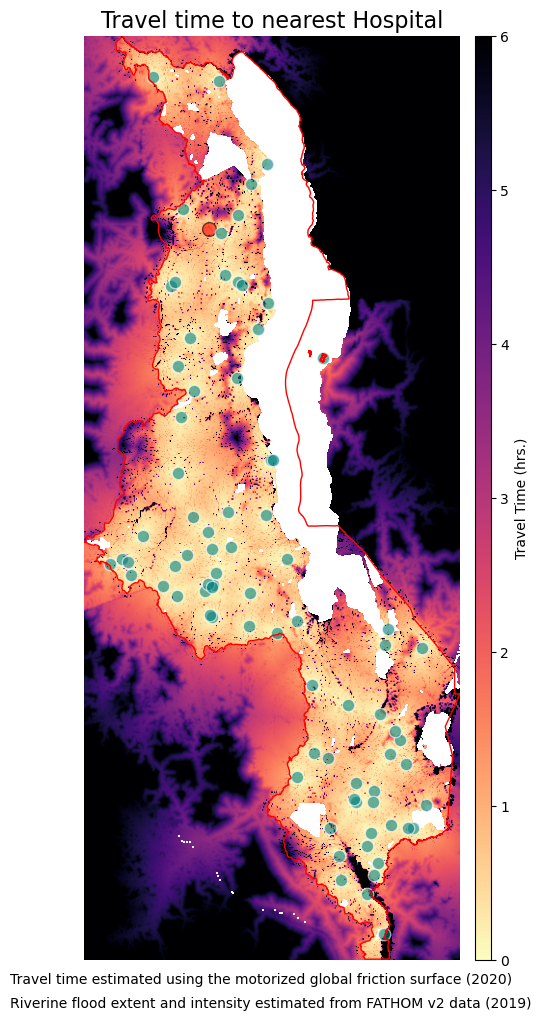

In [214]:
# Single Scenario Plot

figsize = (7, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Hospital", fontsize=16, horizontalalignment='center')
plt.axis('off')
ext = plotting_extent(tt_rio_hosp["1in100"])
im = ax.imshow(tt_rio_hosp["1in200"].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
flood_geodf_hf_hosp["1in200"].plot(ax=ax, facecolor='red', edgecolor='black', markersize=100, alpha=0.6)
dry_geodf_hf_hosp["1in200"].plot(ax=ax, facecolor='teal', edgecolor='white', markersize=80, alpha=0.6)
adm0.plot(ax=ax, facecolor="none", edgecolor='red')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt= "Travel time estimated using the motorized global friction surface (2020)"
txt2 = "Riverine flood extent and intensity estimated from FATHOM v2 data (2019)"
plt.figtext(0.12, 0.09, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.savefig("travel-time-friction_flood100.png", dpi=300, bbox_inches='tight', facecolor='white')

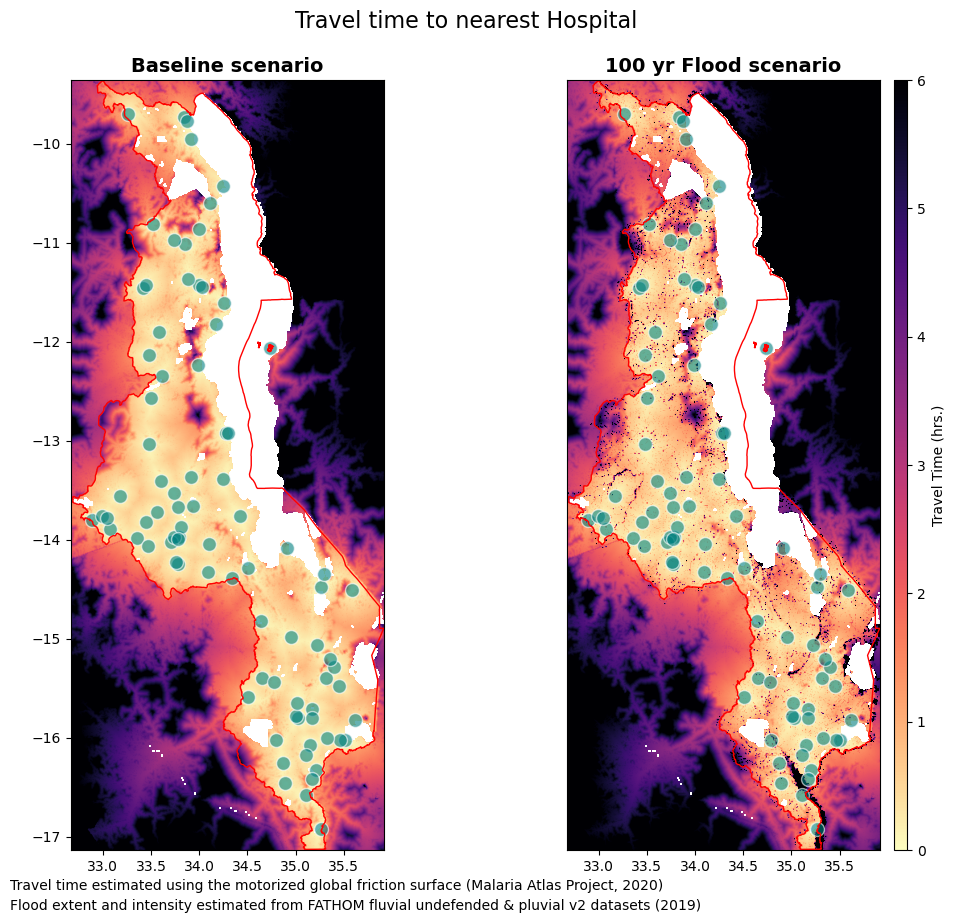

In [216]:
# Multiple Scenario plot

figsize = (12,10)
fig, ax = plt.subplots(1, 2,  figsize = figsize)

fonttitle = {'weight':'bold','size':14}

fig.suptitle("Travel time to nearest Hospital", size = 16, y = 0.95)
ax[0].set_title("Baseline scenario", fontdict=fonttitle)
ax[0].get_xaxis().set_visible(True) # plt.axis('off')
ax[0].get_yaxis().set_visible(True)

ax[1].set_title("100 yr Flood scenario", fontdict=fonttitle)
ax[1].get_xaxis().set_visible(True) # plt.axis('off')
ax[1].get_yaxis().set_visible(False)

ext = plotting_extent(tt_rio_hosp['baseline'])
im = ax[0].imshow(tt_rio_hosp['baseline'].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax[0], facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax[0], facecolor="none", edgecolor='red')

ext = plotting_extent(tt_rio_hosp["1in100"])
im1 = ax[1].imshow(tt_rio_hosp["1in100"].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax[1], facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax[1], facecolor="none", edgecolor='red')

divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im1, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt = "Travel time estimated using the motorized global friction surface (Malaria Atlas Project, 2020)"
txt2 = "Flood extent and intensity estimated from FATHOM fluvial undefended & pluvial v2 datasets (2019)"
plt.figtext(0.12, 0.07, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.05, txt2, wrap=True, horizontalalignment='left', fontsize=10)

plt.savefig(join(out_path, iso, "Travel time to nearest Hospital (1in100) - travel_surf.png"), dpi=300, bbox_inches='tight', facecolor='white')

### Summarize population within 2 hours from Health Facilities

In [219]:
pop = pop_surf.read(1, masked=True)

df_pop = pd.DataFrame(zonal_stats(adm1, pop.filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop'})
df_pop_hosp = df_pop.copy()

pop_120_hospital = dict()
df_pop_120_hospital = dict()
for key in tt_rio_hosp.keys():
    pop_120_hospital[key] = pop*(tt_rio_hosp[key].read(1)<=2)
    df_pop_120_hospital[key] = pd.DataFrame(zonal_stats(adm1, pop_120_hospital[key].filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop_120_hosp_'+key})
    df_pop_hosp = df_pop_hosp.join(df_pop_120_hospital[key])
    df_pop_hosp.loc[:, "hosp_pct_"+key] = df_pop_hosp.loc[:, "pop_120_hosp_"+key]/df_pop_hosp.loc[:, "pop"]*100
    res = adm1.join(df_pop_hosp)

res.head(2)

,ID_0,COUNTRY,ID_1,ADM1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,pop_120_hosp_1in20,hosp_pct_1in20,pop_120_hosp_1in250,hosp_pct_1in250,pop_120_hosp_1in10,hosp_pct_1in10,pop_120_hosp_1in200,hosp_pct_1in200,pop_120_hosp_1in500,hosp_pct_1in500
0,MWI,Malawi,MWI.1_1,Balaka,,,District,District,,MW.BA,...,4.104057e+05,98.752155,4.073450e+05,98.015683,4.105076e+05,98.776669,4.074785e+05,98.047806,405687.250,97.616801
1,MWI,Malawi,MWI.2_1,Blantyre,,,District,District,,MW.BL,...,1.288788e+06,99.838617,1.287898e+06,99.769690,1.289224e+06,99.872373,1.287898e+06,99.769690,1287837.375,99.764975


In [220]:
print(f"Summary of % of pop. within 2 hr. of hospital \n {res.hosp_pct_baseline.describe()}")
print(f"Summary of % of pop. within 2 hr. of hospital given 100yr RP floods \n {res.hosp_pct_1in100.describe()}")


Summary of % of pop. within 2 hr. of hospital 
 count     28.000000
mean      99.311874
std        1.649680
min       92.456799
25%       99.724039
50%       99.928778
75%      100.000000
max      100.000000
Name: hosp_pct_baseline, dtype: float64
Summary of % of pop. within 2 hr. of hospital given 100yr RP floods 
 count    28.000000
mean     96.067982
std       4.252051
min      83.825951
25%      93.933950
50%      97.802810
75%      99.033833
max      99.823793
Name: hosp_pct_1in100, dtype: float64


### Accessibility Maps (Share of pop.)

Percentage of population within 2 hours of driving to the nearest primary care facility, by District (ADM1).​

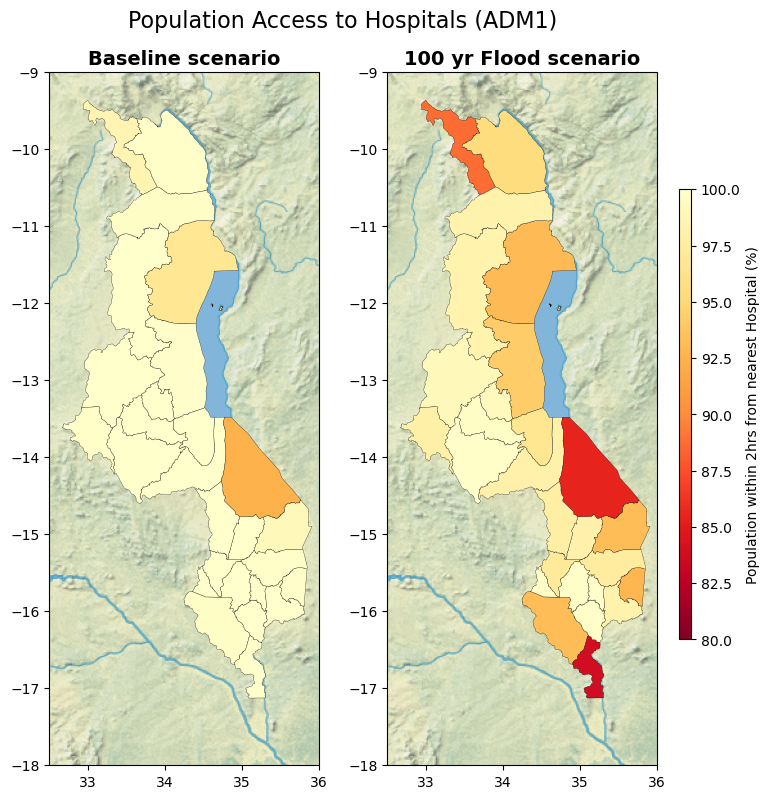

In [221]:
import cartopy.feature as cfeature
import contextily as ctx

projection = ccrs.PlateCarree()

figsize = (8,9)
# fig, ax = plt.subplots(1, 2,  figsize = figsize)
fig = plt.figure(figsize=figsize)
ax1 = fig.add_subplot(1, 2, 1, projection=projection)
ax2 = fig.add_subplot(1, 2, 2, projection=projection, sharex=ax1, sharey=ax1)
fonttitle = {'weight':'bold','size':14}

title = "Population Access to Hospitals (ADM1)"
fig.suptitle(title, size = 16, y = 0.95)
ax1.set_title("Baseline scenario", fontdict=fonttitle)
ax1.get_xaxis().set_visible(True) # plt.axis('off')
ax1.get_yaxis().set_visible(True)

ax2.set_title("100 yr Flood scenario", fontdict=fonttitle)
ax2.get_xaxis().set_visible(True) # plt.axis('off')
ax2.get_yaxis().set_visible(True)


# Define the colormap
cmap = plt.get_cmap('YlOrRd_r')
# Define the normalization 
norm = colors.Normalize(vmin=80, vmax=100)

res.plot(
    ax=ax1, column='hosp_pct_baseline', cmap='YlOrRd_r', legend=False,
    alpha=1, linewidth=0.2, edgecolor='black',
    norm = norm
)

res.plot(
    ax=ax2, column='hosp_pct_1in100', cmap='YlOrRd_r', legend=False,
    alpha=1, linewidth=0.2, edgecolor='black',
    norm = norm
)

ax1.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])
ax2.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm = norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Population within 2hrs from nearest Hospital (%)")

plt.savefig(join(out_path, iso, title+ ".png"), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

### Access to health disaggregated by wealth quintile

Categorize population grid by wealth quintiles, and then summarize the population with access to health (within 2 hours of health facility or hospital)

Hospitals

In [33]:
%%time

# Open Relative Wealth index and Population from Facebook
df_fb_rwi = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_relative_wealth_index.csv'))
geodf_fb = [Point(xy) for xy in zip(df_fb_rwi.longitude, df_fb_rwi.latitude)]
geodf_fb = gpd.GeoDataFrame(df_fb_rwi, crs=epsg, geometry=geodf_fb)
geodf_fb = gpd.sjoin(geodf_fb, adm1[['ADM1','geometry']])

df_fb_pop = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_general_2020.csv'))
df_fb_pop = df_fb_pop.rename(columns={f'{iso.lower()}_general_2020': 'pop_2020'})
    
df_fb_flood_hosp = dict()
for key in tt_rio_hosp.keys():

    # Zonal mean of RWI in tt_rio_hosp cells
    df_fb_flood_hosp[key] = pd.DataFrame(zonal_stats(geodf_fb, tt_rio_hosp[key].read(1, masked = True).filled(), affine=tt_rio_hosp[key].transform, stats='mean', nodata=tt_rio_hosp[key].nodata)).rename(columns={'mean':'tt_hospital_'+key})
    geodf_fb = geodf_fb.join(df_fb_flood_hosp[key])

    # Discretize in quantiles
    geodf_fb.loc[:, "rwi_cut_"+key] = pd.qcut(geodf_fb['rwi'], [0, .2, .4, .6, .8, 1.], labels=['lowest', 'second-lowest', 'middle', 'second-highest', 'highest'])
    
    # Merge RWI and population by matching the grid (quadkey)
    df_fb_pop['quadkey'+key] = df_fb_pop.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    geodf_fb['quadkey'+key] = geodf_fb.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    bing_tile_z14_pop = df_fb_pop.groupby('quadkey'+key, as_index=False)['pop_2020'].sum()

    rwi = geodf_fb.merge(bing_tile_z14_pop[['quadkey'+key, 'pop_2020']], on='quadkey'+key, how='inner')

res_rwi_adm0 = pd.DataFrame()
res_rwi_adm1 = pd.DataFrame()
for key in tt_rio_hosp.keys():

    # Define boolean proximity within 2hrs from hospital
    rwi.loc[:,"tt_hospital_bool_" + key] = rwi['tt_hospital_'+key]<=2
    
    # Aggregate at country level (ADM0)
    pop_adm0 = rwi[['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum()
    hosp_adm0 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm0 = pop_adm0.join(hosp_adm0)
    res_rwi_adm0.loc[:, "hospital_pct_"+key] = rwi_adm0['pop_120_hospital_'+key]/rwi_adm0['pop_2020']

    # Aggregate at region level (ADM1)
    pop_adm1 = rwi[['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum()
    hosp_adm1 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm1 = pop_adm1.join(hosp_adm1)
    res_rwi_adm1.loc[:, "hospital_pct_"+key] = rwi_adm1['pop_120_hospital_'+key]/rwi_adm1['pop_2020']

res_rwi_adm0.reset_index(inplace = True)
res_rwi_adm0 = res_rwi_adm0.rename(columns={'rwi_cut_1in5':'quantiles'})

res_rwi_adm1.reset_index(inplace = True)
res_rwi_adm1 = res_rwi_adm1.rename(columns={'rwi_cut_1in5':'quantiles'})


CPU times: user 11min, sys: 27.5 s, total: 11min 27s
Wall time: 11min 32s


In [44]:
res_rwi_adm0

,quantiles,hospital_pct_baseline,hospital_pct_1in5,hospital_pct_1in10,hospital_pct_1in20,hospital_pct_1in50,hospital_pct_1in75,hospital_pct_1in100,hospital_pct_1in200,hospital_pct_1in250,hospital_pct_1in500,hospital_pct_1in1000
0,lowest,0.968458,0.942968,0.931825,0.923182,0.909324,0.901743,0.894963,0.877782,0.876473,0.867299,0.852240
1,second-lowest,0.969073,0.952441,0.939537,0.931951,0.910010,0.904598,0.896635,0.880010,0.874974,0.858352,0.850143
2,middle,0.958790,0.943652,0.932543,0.925424,0.909380,0.902231,0.894172,0.877119,0.873440,0.851875,0.837238
3,second-highest,0.966567,0.942180,0.932883,0.922187,0.907386,0.901439,0.896703,0.882275,0.879313,0.860477,0.849826
4,highest,0.957686,0.941660,0.933088,0.923505,0.904804,0.896737,0.893224,0.878204,0.877412,0.866729,0.852169


In [34]:
def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if str_start in col]
    non_fd_columns = [col for col in gdf.columns if not str_start in col]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

In [35]:
# Melting for seaborn plot
res_rwi_adm0 = sort_flood_col(res_rwi_adm0, "1in", "in")
res_rwi_adm0_long = pd.melt(res_rwi_adm0, id_vars="quantiles", var_name="scen")
res_rwi_adm0_long.value = res_rwi_adm0_long.value*100
scen = res_rwi_adm0_long.scen.unique()
scen = [s.split("_")[2] for s in scen]

res_rwi_adm1 = sort_flood_col(res_rwi_adm1, "1in", "in")
res_rwi_adm1_long = pd.melt(res_rwi_adm1, id_vars=["ADM1","quantiles"], var_name="scen")
res_rwi_adm1_long.value = res_rwi_adm1_long.value*100

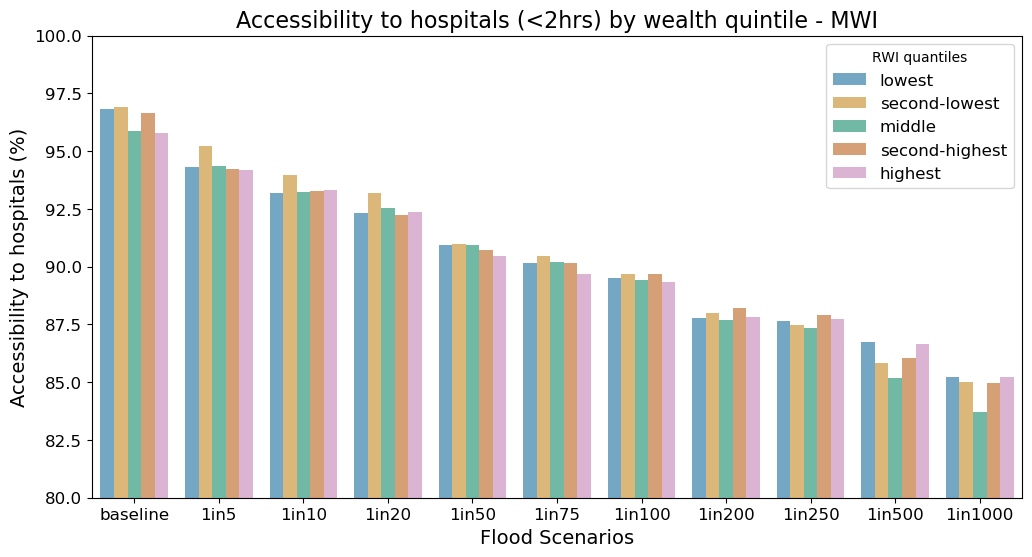

In [52]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
title = "Accessibility to hospitals (<2hrs) by wealth quintile - " + iso
ax0.set_title(title, fontsize = 16)
ax0.set_xticklabels(scen, fontsize = 12)
ax0.tick_params(axis='y', labelsize=12)
ax0.set_xlabel("Flood Scenarios", fontsize = 14)
ax0.set_ylabel("Accessibility to hospitals (%)", fontsize = 14)
ax0.set_ylim(80,100)
ax0 = sns.barplot(
    data=res_rwi_adm0_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6,
)
ax0.legend(loc='upper right', fontsize = 12, title = "RWI quantiles")

plt.savefig(join(out_path, iso, title+ ".png"), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

In [53]:
res_rwi_adm1["hospital_pct_impact"] = (res_rwi_adm1["hospital_pct_1in1000"] - res_rwi_adm1["hospital_pct_baseline"])/res_rwi_adm1["hospital_pct_baseline"]

In [54]:
test = res_rwi_adm1.copy()
test = test[["ADM1", "quantiles", "hospital_pct_impact"]]

quant = pd.DataFrame(test["ADM1"].unique())
for q in test.quantiles.unique().to_list():
    quant["hospital_pct_impact_"+ q] = test[test["quantiles"] == q]["hospital_pct_impact"].values.round(3)*100
    
quant = quant.rename(columns = {quant.columns[0]:"ADM1"})
quant = quant.merge(right = adm1[["ADM1",'geometry']], on = "ADM1", how = "left")
quant = gpd.GeoDataFrame(quant, crs=epsg, geometry="geometry")
# quant = quant*100
quant.head(2)

,ADM1,hospital_pct_impact_lowest,hospital_pct_impact_second-lowest,hospital_pct_impact_middle,hospital_pct_impact_second-highest,hospital_pct_impact_highest,geometry
0,Balaka,-4.9,-14.8,-13.2,-7.6,-12.9,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
1,Blantyre,-15.9,-10.6,-16.2,-8.9,-12.0,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."


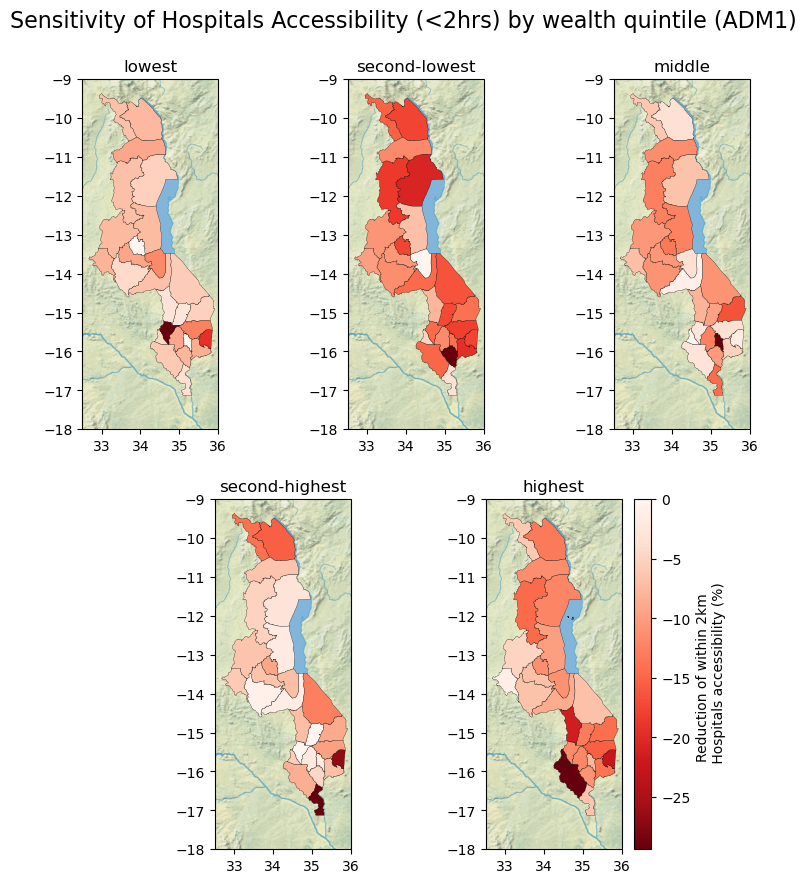

In [62]:
figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 6)

title = "Sensitivity of Hospitals Accessibility (<2hrs) by wealth quintile (ADM1)"
fig.suptitle(title, size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

for i, q in enumerate(quant.columns[1:6]):
    if i < 3:
        ax = fig.add_subplot(gs[0, 2 * i : 2 * i + 2], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, 2 * i - 5 : 2 * i - 3], projection=projection)

    ax.set_title(q.split("_")[3])
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)
    
    cmap = "Reds_r"

    if i == 4:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=True,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "user defined", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'label': "Reduction of within 2km \n Hospitals accessibility (%)",
            # "loc": "upper right",
            # "bbox_to_anchor": (2.7, 1), 
            # 'fontsize': 10,
            # 'fmt': "{:.0%}",
            # 'title_fontsize': 12
        }
    )
    else:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "naturalbreaks", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'title': "Reduction of within 2km \n Hospitals accessibility (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{:.0%}",
            'title_fontsize': 12
        }
    )
        
    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

plt.savefig(os.path.join(out_path, iso, title + ".png"), dpi=150, bbox_inches='tight', facecolor='white')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


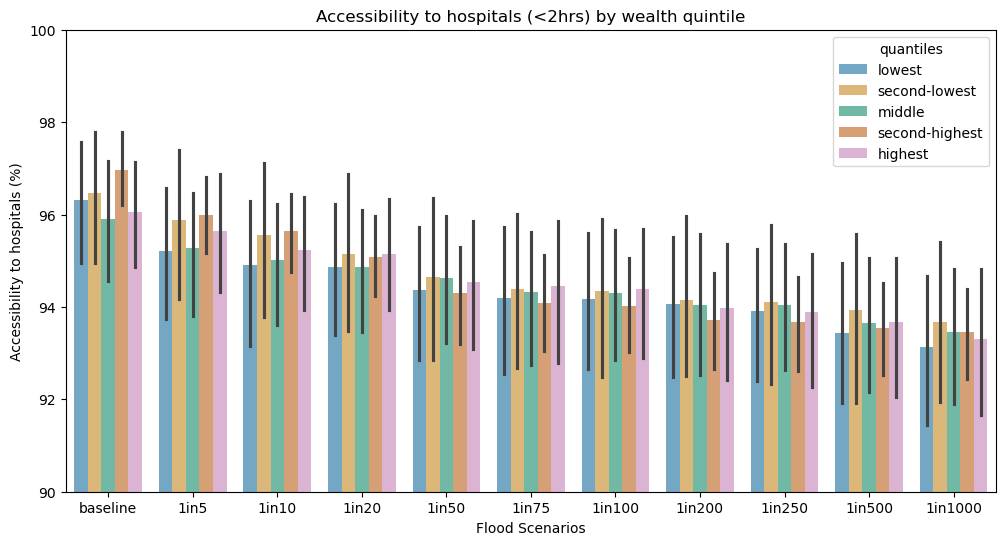

In [355]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm1_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)